# Chromatin Peak to Trough Analysis and Metrics

Summarize the chromatin peak-to-trough ratios for each gene. There will be a few methods we can try. 

1. First, let's get an idea of what the peak-to-trough ratio values are for all the chromatin cells for all genes.
2. Then, try a few threshold values to get a sense of how we can partition the genes into cell cycling and non-cell cycling gene groups


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from cc_src.peak_to_trough_anaysis import PeakToTroughAnalysis

In [3]:
analysis = PeakToTroughAnalysis()

Created a dictionary of PTR arrays of size: 5402
So, there were 372 genes that did not deconvolve
Created a numpy array of all deconvolved gene PTRs of shape: (5774, 3, 9)


[nan nan nan]


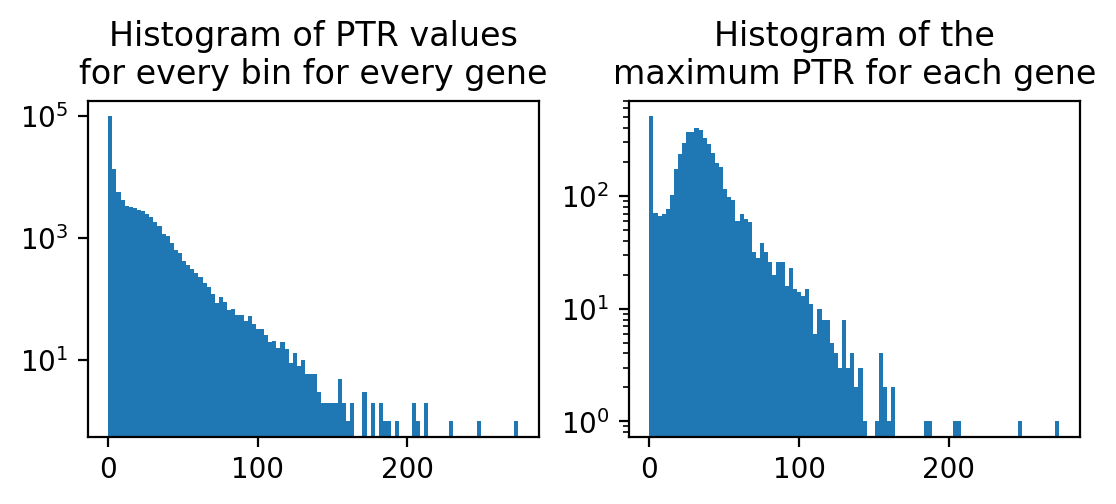

In [4]:
analysis.plot_histograms()

In [5]:
max_ptr_values = analysis.all_ptr_arr.max(axis=1).max(axis=1)
max_ptr_values = max_ptr_values[~np.isnan(max_ptr_values)]
max_ptr_values

array([45.42976721,  1.17429128,  0.        , ...,  0.        ,
        0.        ,  0.        ])

In [12]:
# Drop nan values
all_ptr_values = analysis.all_ptr_arr.flatten()
all_ptr_values = all_ptr_values[~np.isnan(all_ptr_values)]

# Let's try some thresholds, then count how many genes are above and below these thresholds
prop_thresholds = [0.1, 0.15, 0.3, 0.6, 0.75, 0.9, 0.95, 0.975, 0.999]
threshold_values = []
higher_genes = []
lower_genes = []
n = len(max_ptr_values)

print(f"For Peak-to-trough (PTR) thresholds of:")
print("\n--------------------------------------------------------------------------\n")
for i in range(len(prop_thresholds)):
    prop = prop_thresholds[i]
    threshold = np.quantile(all_ptr_values, prop)

    genes_higher_than_thresh = len(max_ptr_values[max_ptr_values > threshold])
    genes_all_lower_than_thresh = len(max_ptr_values[max_ptr_values < threshold])
    
    threshold_values.append(threshold)
    higher_genes.append(genes_higher_than_thresh)
    lower_genes.append(genes_all_lower_than_thresh)
    
    print(f"{threshold:.1f} - percentile: {prop*100:.1f}%")
    print(f"    {(genes_higher_than_thresh)}/{n} "
          f"({(genes_higher_than_thresh)/n*100.:.1f}%) "
          "genes exceed this value for any cell")
    
    print(f"    {(genes_all_lower_than_thresh)}/{n} "
          f"({(genes_all_lower_than_thresh)/n*100.:.1f}%) "
          "genes are below this value for all cells")
    
    print("\n--------------------------------------------------------------------------\n")

threshold_counts_df = pd.DataFrame({'threshold': threshold_values, 
                                    'proportion': prop_thresholds,
                                    'num_higher': higher_genes,
                                    'num_less': lower_genes})


For Peak-to-trough (PTR) thresholds of:

--------------------------------------------------------------------------

1.0 - percentile: 10.0%
    4969/5344 (93.0%) genes exceed this value for any cell
    375/5344 (7.0%) genes are below this value for all cells

--------------------------------------------------------------------------

1.0 - percentile: 15.0%
    4968/5344 (93.0%) genes exceed this value for any cell
    376/5344 (7.0%) genes are below this value for all cells

--------------------------------------------------------------------------

1.1 - percentile: 30.0%
    4938/5344 (92.4%) genes exceed this value for any cell
    406/5344 (7.6%) genes are below this value for all cells

--------------------------------------------------------------------------

2.1 - percentile: 60.0%
    4844/5344 (90.6%) genes exceed this value for any cell
    500/5344 (9.4%) genes are below this value for all cells

--------------------------------------------------------------------------


In [ ]:


# Need to clarify how and why we are summarizing the peak to trough ratios











<BarContainer object of 9 artists>

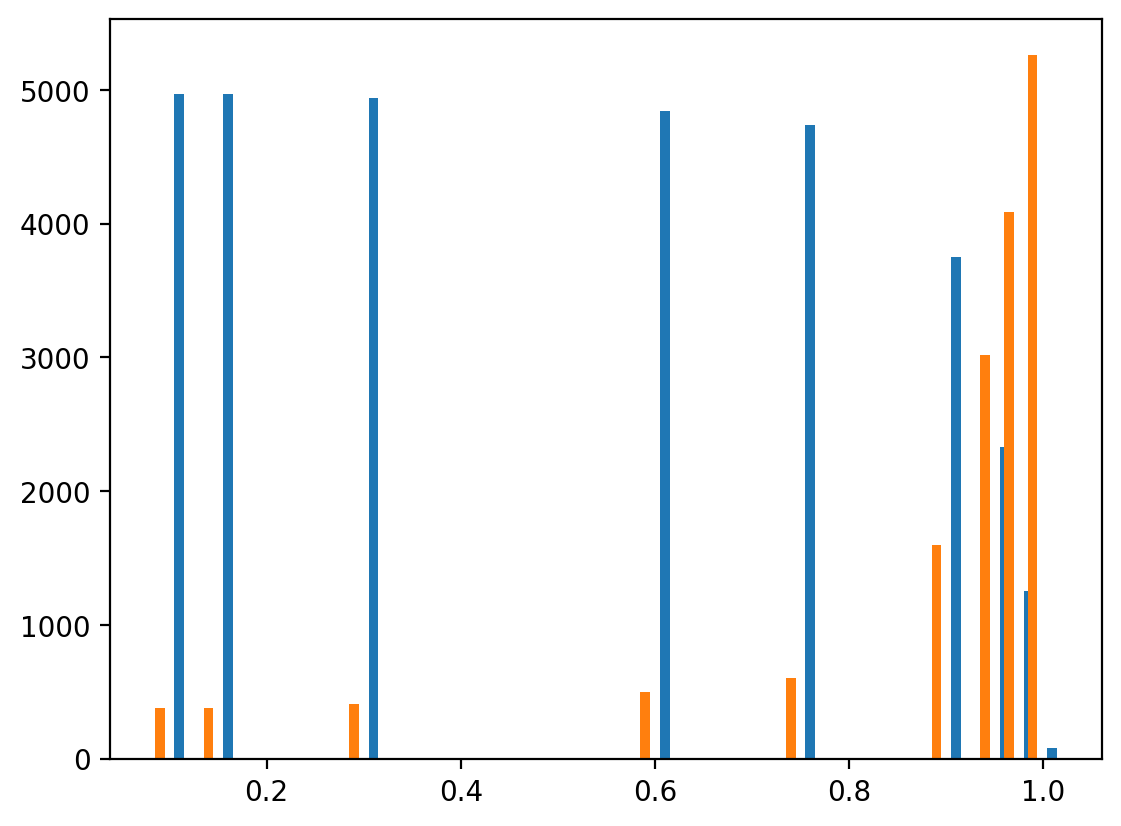

In [25]:
plt.bar(threshold_counts_df.proportion+0.01, threshold_counts_df.num_higher, width=0.01)
plt.bar(threshold_counts_df.proportion-0.01, threshold_counts_df.num_less, width=0.01)

<BarContainer object of 9 artists>

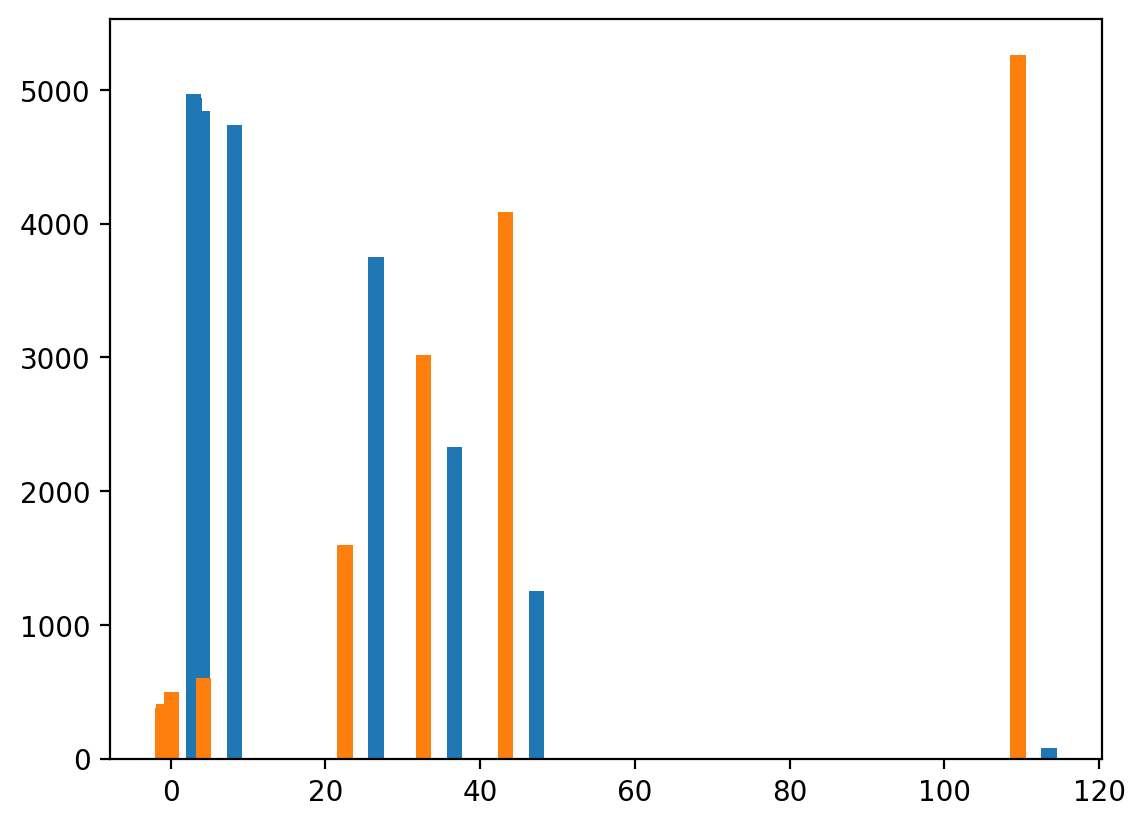

In [21]:
plt.bar(threshold_counts_df.threshold+2, threshold_counts_df.num_higher, width=2)
plt.bar(threshold_counts_df.threshold-2, threshold_counts_df.num_less, width=2)